# 🔬 THỰC NGHIỆM CHỨNG MINH KHOA HỌC: HUẤN LUYỆN TỪ ĐẦU & PHÂN TÍCH VAI TRÒ CỦA DECOMPOSITION VÀ PHYSICAL STATS

Notebook này được thiết kế để thực hiện quy trình hoàn chỉnh từ **huấn luyện từ đầu (train from scratch)** đến **đánh giá so sánh trực quan** của 4 cấu hình mấu chốt trong nghiên cứu mô hình **Hybrid Mamba-CNN** chẩn đoán dị thường vòng bi:

1. **Vanilla (Mamba-CNN thuần túy)**: Tắt phân tách chuỗi động và đặc trưng vật lý (`use_decomposition: false, use_stats: false`).
2. **Decomposition-Only**: Chỉ bật phân tách chuỗi động, tắt đặc trưng vật lý (`use_decomposition: true, use_stats: false`).
3. **Stats-Only**: Tắt phân tách chuỗi động, chỉ bật đặc trưng vật lý (`use_decomposition: false, use_stats: true`).
4. **Proposed (Decomposition & Stats)**: Bật cả hai module (`use_decomposition: true, use_stats: true`).

## 🎯 Mục tiêu khoa học:
- **Huấn luyện thực tế từ đầu** cho từng biến thể để so sánh khách quan trọng số học được dưới các ràng buộc kiến trúc khác nhau.
- **Chứng minh tính đúng đắn của cấu hình đề xuất (Proposed)**: Đạt độ mượt tốt nhất nhờ Decomposition và độ nhạy cảnh báo sớm vượt trội nhờ Physical Stats.

In [1]:
!pip install mamba-ssm --no-build-isolation

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 MB 45.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 82.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.8/260.8 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 MB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.3/29.3 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.8/897.8 kB 52.7 MB/s eta 0:00:00
  Created wheel for mamba-ssm: filename=mamba_ssm-2.3.2.post1-cp312-cp312-linux_x86_64.whl size=322288410 sha256=7a67070c1e7e99c95abd1319623f044e8a1b3fb46f774bfdea949f0a4fc79638
  Stored in directory: /root/.cache/pip/wheels/da/67/03/99148d6eeaa4ec2855d71295ac83bcbc8ba7b41a2982992c63
Successfully built mamba-ssm


In [2]:
import os
import sys
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import yaml
import pandas as pd
import time
from tqdm.auto import tqdm

# 1. Phát hiện môi trường Kaggle và cấu hình đường dẫn dự án
is_kaggle = os.path.exists('/kaggle')
print(f'Is running on Kaggle: {is_kaggle}')

if is_kaggle:
    kaggle_source_root = '/kaggle/input/datasets/sunbv21/mamba-sft-source'
    if kaggle_source_root not in sys.path:
        sys.path.append(kaggle_source_root)
    project_root = kaggle_source_root
    
    # Processed data directory on Kaggle
    data_processed_dir = "/kaggle/input/datasets/sunbv21/dataset-bearings"
    train_dirs = [os.path.join(data_processed_dir, "B02"), os.path.join(data_processed_dir, "B05")]
    test_dirs = [os.path.join(data_processed_dir, d) for d in ["B01", "B03", "B04", "B05"]]
    
    models_dir = "/kaggle/working/results/models"
    plot_save_dir = "/kaggle/working/results/plots"
    config_path = os.path.join(project_root, "configs/snano_vanilla.yaml")
    print(f'-> [Kaggle] project_root: {project_root}')
    print(f'-> [Kaggle] models_dir: {models_dir}')
else:
    project_root = os.path.abspath(os.path.join(os.getcwd(), "../"))
    if project_root not in sys.path:
        sys.path.append(project_root)
        
    data_processed_dir = os.path.join(project_root, "data/processed")
    train_dirs = [os.path.join(data_processed_dir, "B02"), os.path.join(data_processed_dir, "B05")]
    test_dirs = [os.path.join(data_processed_dir, d) for d in ["B01", "B03", "B04", "B05"]]
    
    models_dir = os.path.join(project_root, "results/models")
    plot_save_dir = os.path.join(project_root, "results/plots")
    config_path = os.path.join(project_root, "configs/snano_vanilla.yaml")
    print(f'-> [Local] project_root: {project_root}')
    print(f'-> [Local] models_dir: {models_dir}')

from src.models.mamba import HybridMambaCNN
from src.data import MultiBearingDataset, BearingDataset
from src.evaluation.anomaly_scorer import calculate_anomaly_score
from src.evaluation.metrics import calculate_threshold_pot

print("Imports hoàn tất thành công.")

Is running on Kaggle: True
-> [Kaggle] project_root: /kaggle/input/datasets/sunbv21/mamba-sft-source
-> [Kaggle] models_dir: /kaggle/working/results/models
Imports hoàn tất thành công.


In [3]:
# --- NẠP DỮ LIỆU HUẤN LUYỆN (B02 & B05) ---
print("Đang tải dữ liệu huấn luyện để trích xuất thống kê điều kiện vận hành (Operating Conditions)...")
train_dataset = MultiBearingDataset(
    train_dirs, lookback=512, horizon=128, stride=1024, split='train',
    file_sample_ratio=1, train_ratio=0.5, skip_ratio=0.1,
    normalize=False, highpass_freq=1000, sampling_rate=128000, label_strategy='rms'
)
oc_stats = train_dataset.oc_stats

print("Đang tải dữ liệu validation...")
val_dataset = MultiBearingDataset(
    train_dirs, lookback=512, horizon=128, stride=1024, split='val',
    file_sample_ratio=1, oc_stats=oc_stats, train_ratio=0.5, skip_ratio=0.1,
    normalize=False, highpass_freq=1000, sampling_rate=128000, label_strategy='rms'
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=128, shuffle=False)

print(f"\nTải dữ liệu thành công. Số mẫu Train: {len(train_dataset):,}, Số mẫu Val: {len(val_dataset):,}")

Đang tải dữ liệu huấn luyện để trích xuất thống kê điều kiện vận hành (Operating Conditions)...
Đang tải dữ liệu validation...

Tải dữ liệu thành công. Số mẫu Train: 84,400, Số mẫu Val: 42,400


In [4]:
# --- ĐỊNH NGHĨA EARLY STOPPING & CẤU HÌNH CONFIG DÙNG CHUNG ---
class EarlyStopping:
    def __init__(self, patience=3, verbose=False, delta=0, path='checkpoint.pt'):
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}). Saving model...')
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def get_model_config(use_decomp, use_stats):
    import copy
    import yaml
    with open(config_path, 'r', encoding='utf-8') as f:
        cfg = yaml.safe_load(f)
    
    # Đồng bộ hóa các tên biến cấu hình giữa Data và Model
    cfg['model']['forecast_len'] = cfg['data'].get('horizon', 128)
    cfg['model']['lookback'] = cfg['data'].get('lookback', 512)
    cfg['model']['stride'] = cfg['model'].get('patch_stride', 32)
    cfg['model']['in_channels'] = 2
    
    # Ghi đè động các biến cấu trúc của Ablation Study
    cfg['model']['use_decomposition'] = use_decomp
    cfg['model']['use_stats'] = use_stats
    cfg['model']['use_revin'] = False
    cfg['model']['use_multiscale'] = False
    return cfg

In [5]:
# --- ENGINE HUẤN LUYỆN TỔNG QUÁT TỪ ĐẦU ---
def train_model(variant_name, use_decomp, use_stats, epochs=5):
    print(f"\n🚀 BẮT ĐẦU HUẤN LUYỆN BIẾN THỂ: {variant_name} (Decomp: {use_decomp}, Stats: {use_stats})")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    model_config = get_model_config(use_decomp, use_stats)
    model = HybridMambaCNN(model_config).to(device)
    
    os.makedirs(models_dir, exist_ok=True)
    checkpoint_path = os.path.join(models_dir, f"mamba1_hybrid_snano_{variant_name.lower()}_best.pth")
    
    optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
    criterion = nn.HuberLoss(delta=1.0)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=5e-6)
    scaler = torch.amp.GradScaler('cuda') if device == 'cuda' else None
    
    early_stopping = EarlyStopping(patience=3, verbose=True, path=checkpoint_path)
    
    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0
        pbar = tqdm(train_loader, desc=f"{variant_name} - Epoch {epoch}/{epochs}")
        
        for batch in pbar:
            x, y = batch[0].to(device), batch[1].to(device)
            stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
            
            optimizer.zero_grad()
            with torch.amp.autocast('cuda', enabled=(device == 'cuda')):
                if stats is not None and use_stats:
                    y_pred = model(x, stats)
                else:
                    y_pred = model(x)
                loss = criterion(y_pred, y)
                
            if scaler:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
                
            total_loss += loss.item()
            pbar.set_postfix({'loss': loss.item()})
            
        # Validation Phase
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch[0].to(device), batch[1].to(device)
                stats = batch[2].to(device) if len(batch) > 2 and batch[2].shape[-1] == 8 else None
                with torch.amp.autocast('cuda', enabled=(device == 'cuda')):
                    if stats is not None and use_stats:
                        y_pred = model(x, stats)
                    else:
                        y_pred = model(x)
                    loss = criterion(y_pred, y)
                val_loss += loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        print(f"[{variant_name} - Epoch {epoch}] Train Loss: {total_loss/len(train_loader):.6f} | Val Loss: {avg_val_loss:.6f}")
        
        scheduler.step()
        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print("Early stopping kích hoạt. Kết thúc sớm.")
            break
            
    print(f"✓ Hoàn thành huấn luyện {variant_name}. Checkpoint tốt nhất được lưu tại: {checkpoint_path}")

In [6]:
# --- THỰC HIỆN HUẤN LUYỆN 4 BIẾN THỂ TỪ ĐẦU ---
# Mặc định huấn luyện 5 epochs để chạy nhanh, hãy tăng lên 10-15 epochs để đạt độ hội tụ tối đa.
EPOCHS = 10

train_model('Vanilla', use_decomp=False, use_stats=False, epochs=EPOCHS)
train_model('Decomp-Only', use_decomp=True, use_stats=False, epochs=EPOCHS)
train_model('Stats-Only', use_decomp=False, use_stats=True, epochs=EPOCHS)
train_model('Proposed', use_decomp=True, use_stats=True, epochs=EPOCHS)


🚀 BẮT ĐẦU HUẤN LUYỆN BIẾN THỂ: Vanilla (Decomp: False, Stats: False)


Vanilla - Epoch 1/10:   0%|          | 0/660 [00:00<?, ?it/s]

[Vanilla - Epoch 1] Train Loss: 0.168726 | Val Loss: 0.137994
Validation loss decreased (inf --> 0.137994). Saving model...


Vanilla - Epoch 2/10:   0%|          | 0/660 [00:00<?, ?it/s]

[Vanilla - Epoch 2] Train Loss: 0.130728 | Val Loss: 0.127522
Validation loss decreased (0.137994 --> 0.127522). Saving model...


...

[Proposed - Epoch 8] Train Loss: 0.122111 | Val Loss: 0.123343
Validation loss decreased (0.123601 --> 0.123343). Saving model...


Proposed - Epoch 9/10:   0%|          | 0/660 [00:00<?, ?it/s]

[Proposed - Epoch 9] Train Loss: 0.121432 | Val Loss: 0.122928
Validation loss decreased (0.123343 --> 0.122928). Saving model...


Proposed - Epoch 10/10:   0%|          | 0/660 [00:00<?, ?it/s]

[Proposed - Epoch 10] Train Loss: 0.121011 | Val Loss: 0.122690
Validation loss decreased (0.122928 --> 0.122690). Saving model...
✓ Hoàn thành huấn luyện Proposed. Checkpoint tốt nhất được lưu tại: /kaggle/working/results/models/mamba1_hybrid_snano_proposed_best.pth


In [7]:
# --- ENGINE ĐÁNH GIÁ VÒNG ĐỜI VÒNG BI CHO TỪNG MODEL ĐÃ HUẤN LUYỆN ---
def evaluate_bearing_with_config(bearing_id, model_variant, device, use_stats, step=10):
    checkpoint_name = f"mamba1_hybrid_snano_{model_variant.lower()}_best.pth"
    checkpoint_path = os.path.join(models_dir, checkpoint_name)
    
    use_decomp = (model_variant in ['Decomp-Only', 'Proposed'])
    model_config = get_model_config(use_decomp, use_stats)
    model = HybridMambaCNN(model_config)
    
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=device, weights_only=True))
        print(f"  ✓ Đã nạp thành công trọng số mô hình: {model_variant}")
    else:
        print(f"  ⚠️ CẢNH BÁO: Không tìm thấy checkpoint cho {model_variant} tại {checkpoint_path}! Sử dụng trọng số ngẫu nhiên.")
        
    model.to(device)
    model.eval()
    
    processed_dir = os.path.join(data_processed_dir, bearing_id)
    if not os.path.exists(processed_dir):
        print(f"Bỏ qua {bearing_id}: Không tìm thấy thư mục dữ liệu.")
        return None
    
    dataset = BearingDataset(
        processed_dir, lookback=512, horizon=128, window_stride=1024, split='test', 
        normalize=False, skip_ratio=0.0, train_ratio=0.0
    )
    
    all_files = dataset.files
    eval_files = all_files[::step]
    
    num_stats = 8
    results = {'indices': [], 'mse': [], 'rms': [], 'kurtosis': []}
    
    with torch.no_grad():
        for idx, f_name in enumerate(eval_files):
            actual_idx = idx * step
            f_path = os.path.join(processed_dir, f_name)
            signal_data = torch.load(f_path, map_location='cpu', weights_only=True)
            
            # Tính toán Kurtosis thực tế của toàn bộ file tín hiệu làm minh chứng cơ học
            mean_sig = signal_data.mean(dim=-1, keepdim=True)
            std_sig = signal_data.std(dim=-1, keepdim=True)
            z_sig = (signal_data - mean_sig) / (std_sig + 1e-8)
            kurt_val = torch.mean(z_sig**4, dim=-1).mean().item()
            
            # Lấy 5 cửa sổ cách đều trong file tín hiệu để tính toán
            win_starts = np.linspace(0, signal_data.shape[1] - 512 - 128, 5, dtype=int)
            file_errs = []
            
            for start in win_starts:
                x = signal_data[:, start:start+512]
                y = signal_data[:, start+512:start+512+128]
                
                x_gpu = x.unsqueeze(0).to(device)
                y_gpu = y.unsqueeze(0).to(device)
                
                if use_stats:
                    # Tính toán các chỉ số thống kê đặc trưng vật lý
                    mean = x.mean(dim=-1, keepdim=True)
                    std = x.std(dim=-1, keepdim=True)
                    rms = torch.sqrt(torch.mean(x**2, dim=-1, keepdim=True))
                    peak = torch.max(torch.abs(x), dim=-1, keepdim=True)[0]
                    z = (x - mean) / (std + 1e-8)
                    skew = torch.mean(z**3, dim=-1, keepdim=True)
                    kurt = torch.mean(z**4, dim=-1, keepdim=True)
                    crest = peak / (rms + 1e-8)
                    shape = rms / (torch.mean(torch.abs(x), dim=-1, keepdim=True) + 1e-8)
                    
                    all_stats_list = [mean, std, rms, peak, skew, kurt, crest, shape]
                    stats_tensor = torch.cat(all_stats_list[:num_stats], dim=-1).unsqueeze(0).to(device)
                    
                    y_pred = model(x_gpu, stats=stats_tensor.unsqueeze(1))
                else:
                    y_pred = model(x_gpu)
                    
                mse = calculate_anomaly_score(y_gpu, y_pred, metric='mse', normalized=False).item()
                file_errs.append(mse)
            
            results['indices'].append(actual_idx)
            results['mse'].append(np.mean(file_errs))
            results['rms'].append(dataset.file_rms[f_name])
            results['kurtosis'].append(kurt_val)
            
    return results

In [8]:
# --- THỰC HIỆN ĐÁNH GIÁ 4 MÔ HÌNH HUẤN LUYỆN TRÊN TOÀN BỘ VÒNG ĐỜI ---
bearing_ids = ['B01', 'B02', 'B03', 'B04', 'B05']
device = "cuda" if torch.cuda.is_available() else "cpu"

configs_to_test = {
    'Vanilla': {'use_stats': False},
    'Decomp-Only': {'use_stats': False},
    'Stats-Only': {'use_stats': True},
    'Proposed': {'use_stats': True}
}

FAST_STEP = 10
comparison_results = {}

for b_id in bearing_ids:
    print(f"\n👉 Bắt đầu phân tích Vòng bi: {b_id}...")
    comparison_results[b_id] = {}
    for cfg_name, cfg_vals in configs_to_test.items():
        print(f"  Đang đánh giá mô hình: {cfg_name}...")
        res = evaluate_bearing_with_config(
            b_id, cfg_name, device, 
            use_stats=cfg_vals['use_stats'], 
            step=FAST_STEP
        )
        if res:
            comparison_results[b_id][cfg_name] = res
            print(f"  ✓ Đã hoàn thành đánh giá: {cfg_name}")


👉 Bắt đầu phân tích Vòng bi: B01...
  Đang đánh giá mô hình: Vanilla...
  ✓ Đã nạp thành công trọng số mô hình: Vanilla
  ✓ Đã hoàn thành đánh giá: Vanilla
  Đang đánh giá mô hình: Decomp-Only...
  ✓ Đã nạp thành công trọng số mô hình: Decomp-Only
  ✓ Đã hoàn thành đánh giá: Decomp-Only
  Đang đánh giá mô hình: Stats-Only...
  ✓ Đã nạp thành công trọng số mô hình: Stats-Only
  ✓ Đã hoàn thành đánh giá: Stats-Only
  Đang đánh giá mô hình: Proposed...
  ✓ Đã nạp thành công trọng số mô hình: Proposed
  ✓ Đã hoàn thành đánh giá: Proposed

👉 Bắt đầu phân tích Vòng bi: B02...
  Đang đánh giá mô hình: Vanilla...
  ✓ Đã nạp thành công trọng số mô hình: Vanilla
  ✓ Đã hoàn thành đánh giá: Vanilla
  Đang đánh giá mô hình: Decomp-Only...
  ✓ Đã nạp thành công trọng số mô hình: Decomp-Only
  ✓ Đã hoàn thành đánh giá: Decomp-Only
  Đang đánh giá mô hình: Stats-Only...
  ✓ Đã nạp thành công trọng số mô hình: Stats-Only
  ✓ Đã hoàn thành đánh giá: Stats-Only
  Đang đánh giá mô hình: Proposed...
  ✓ 

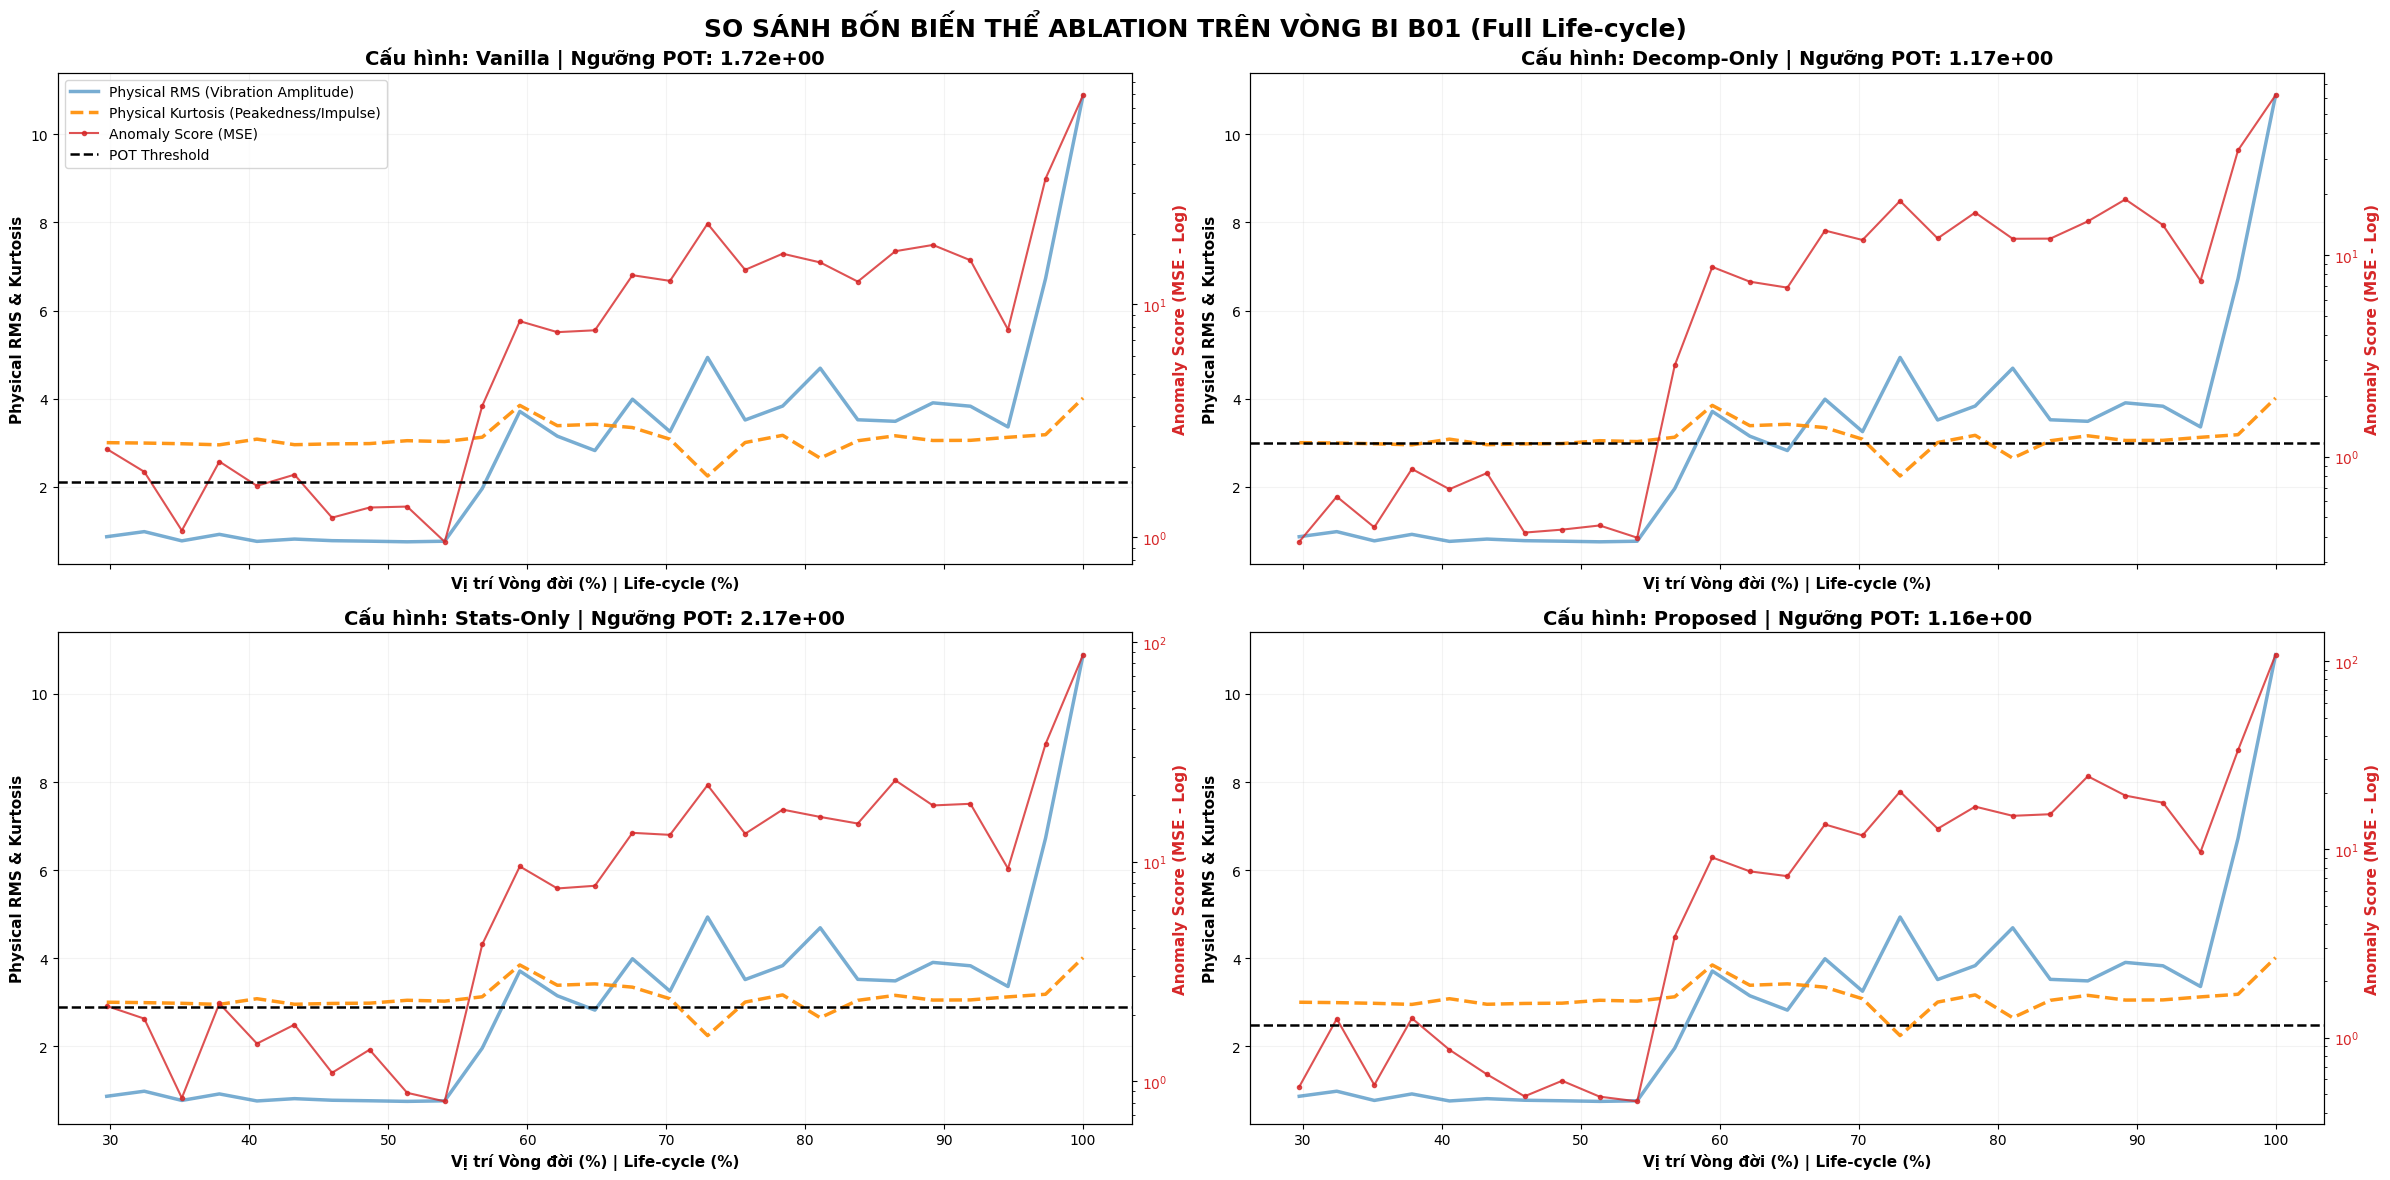

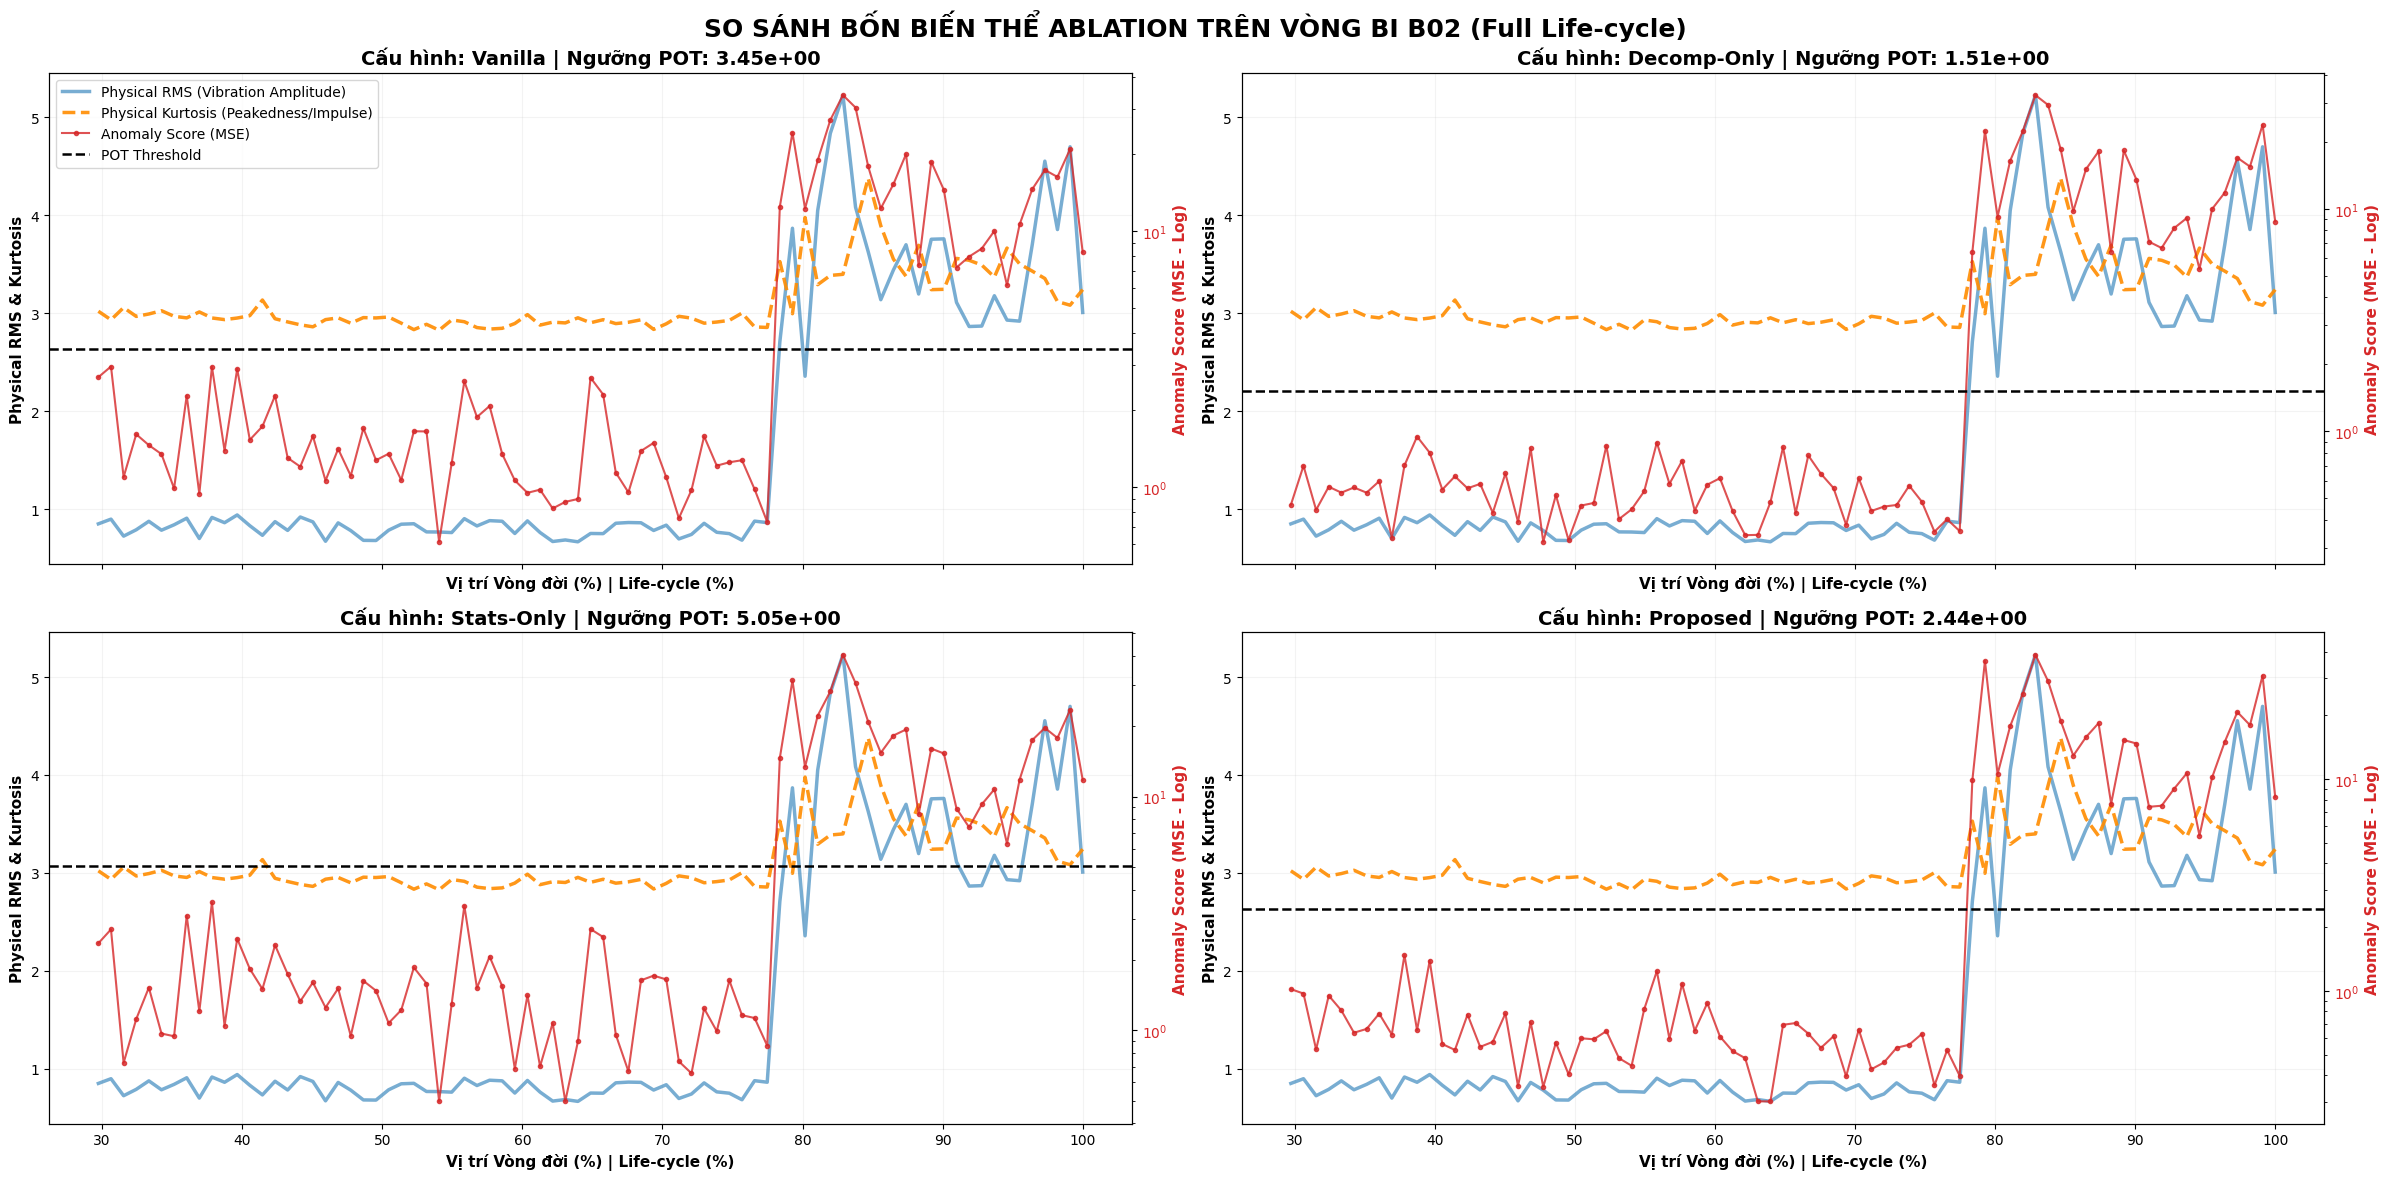

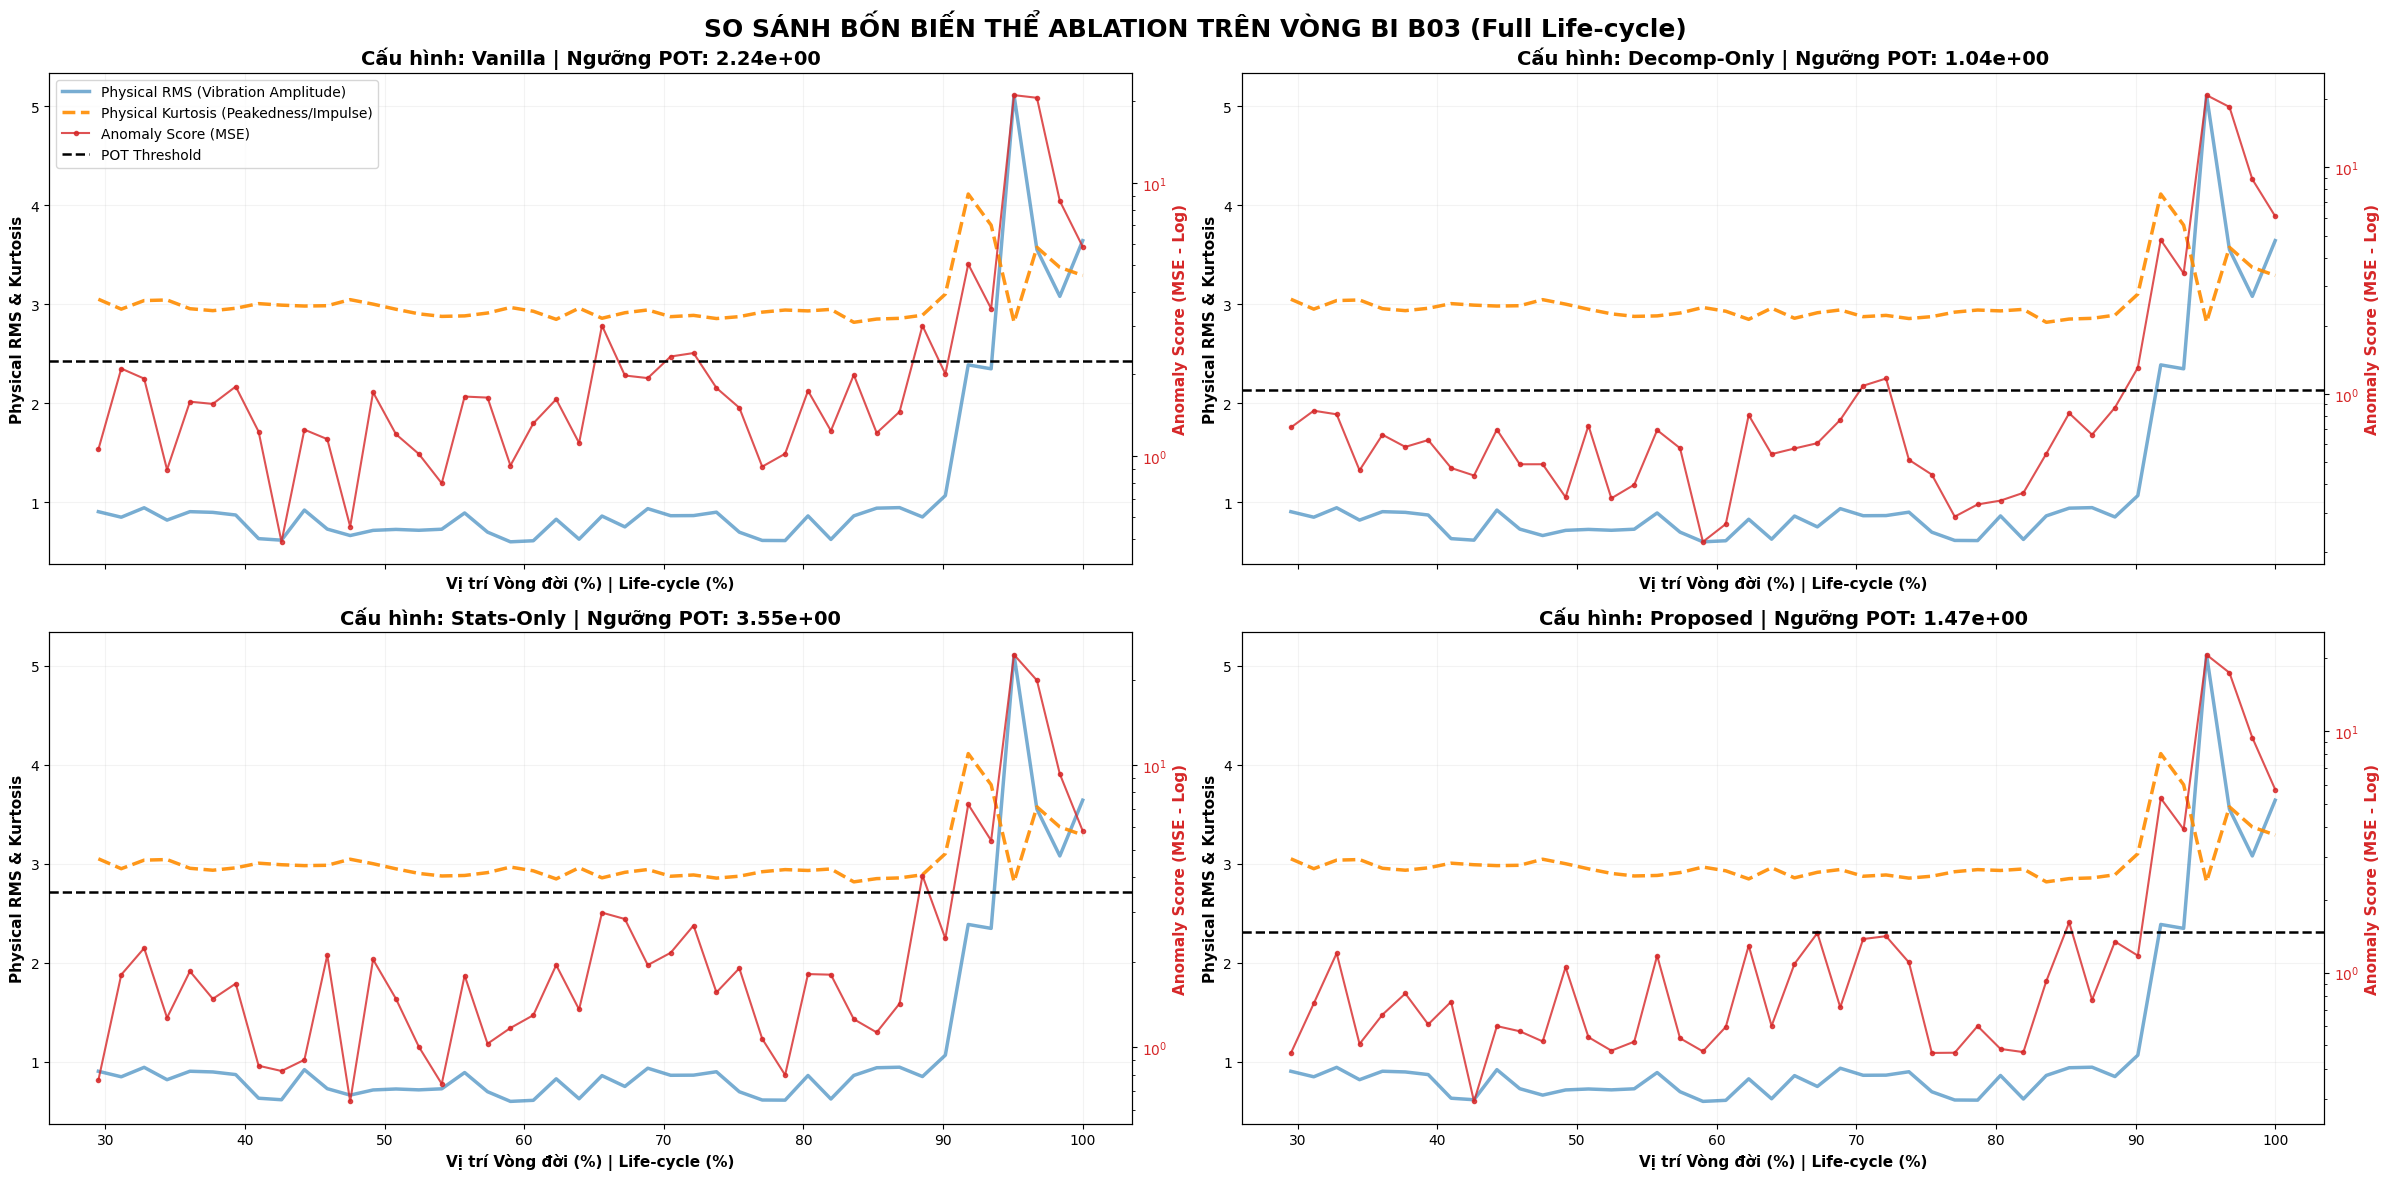

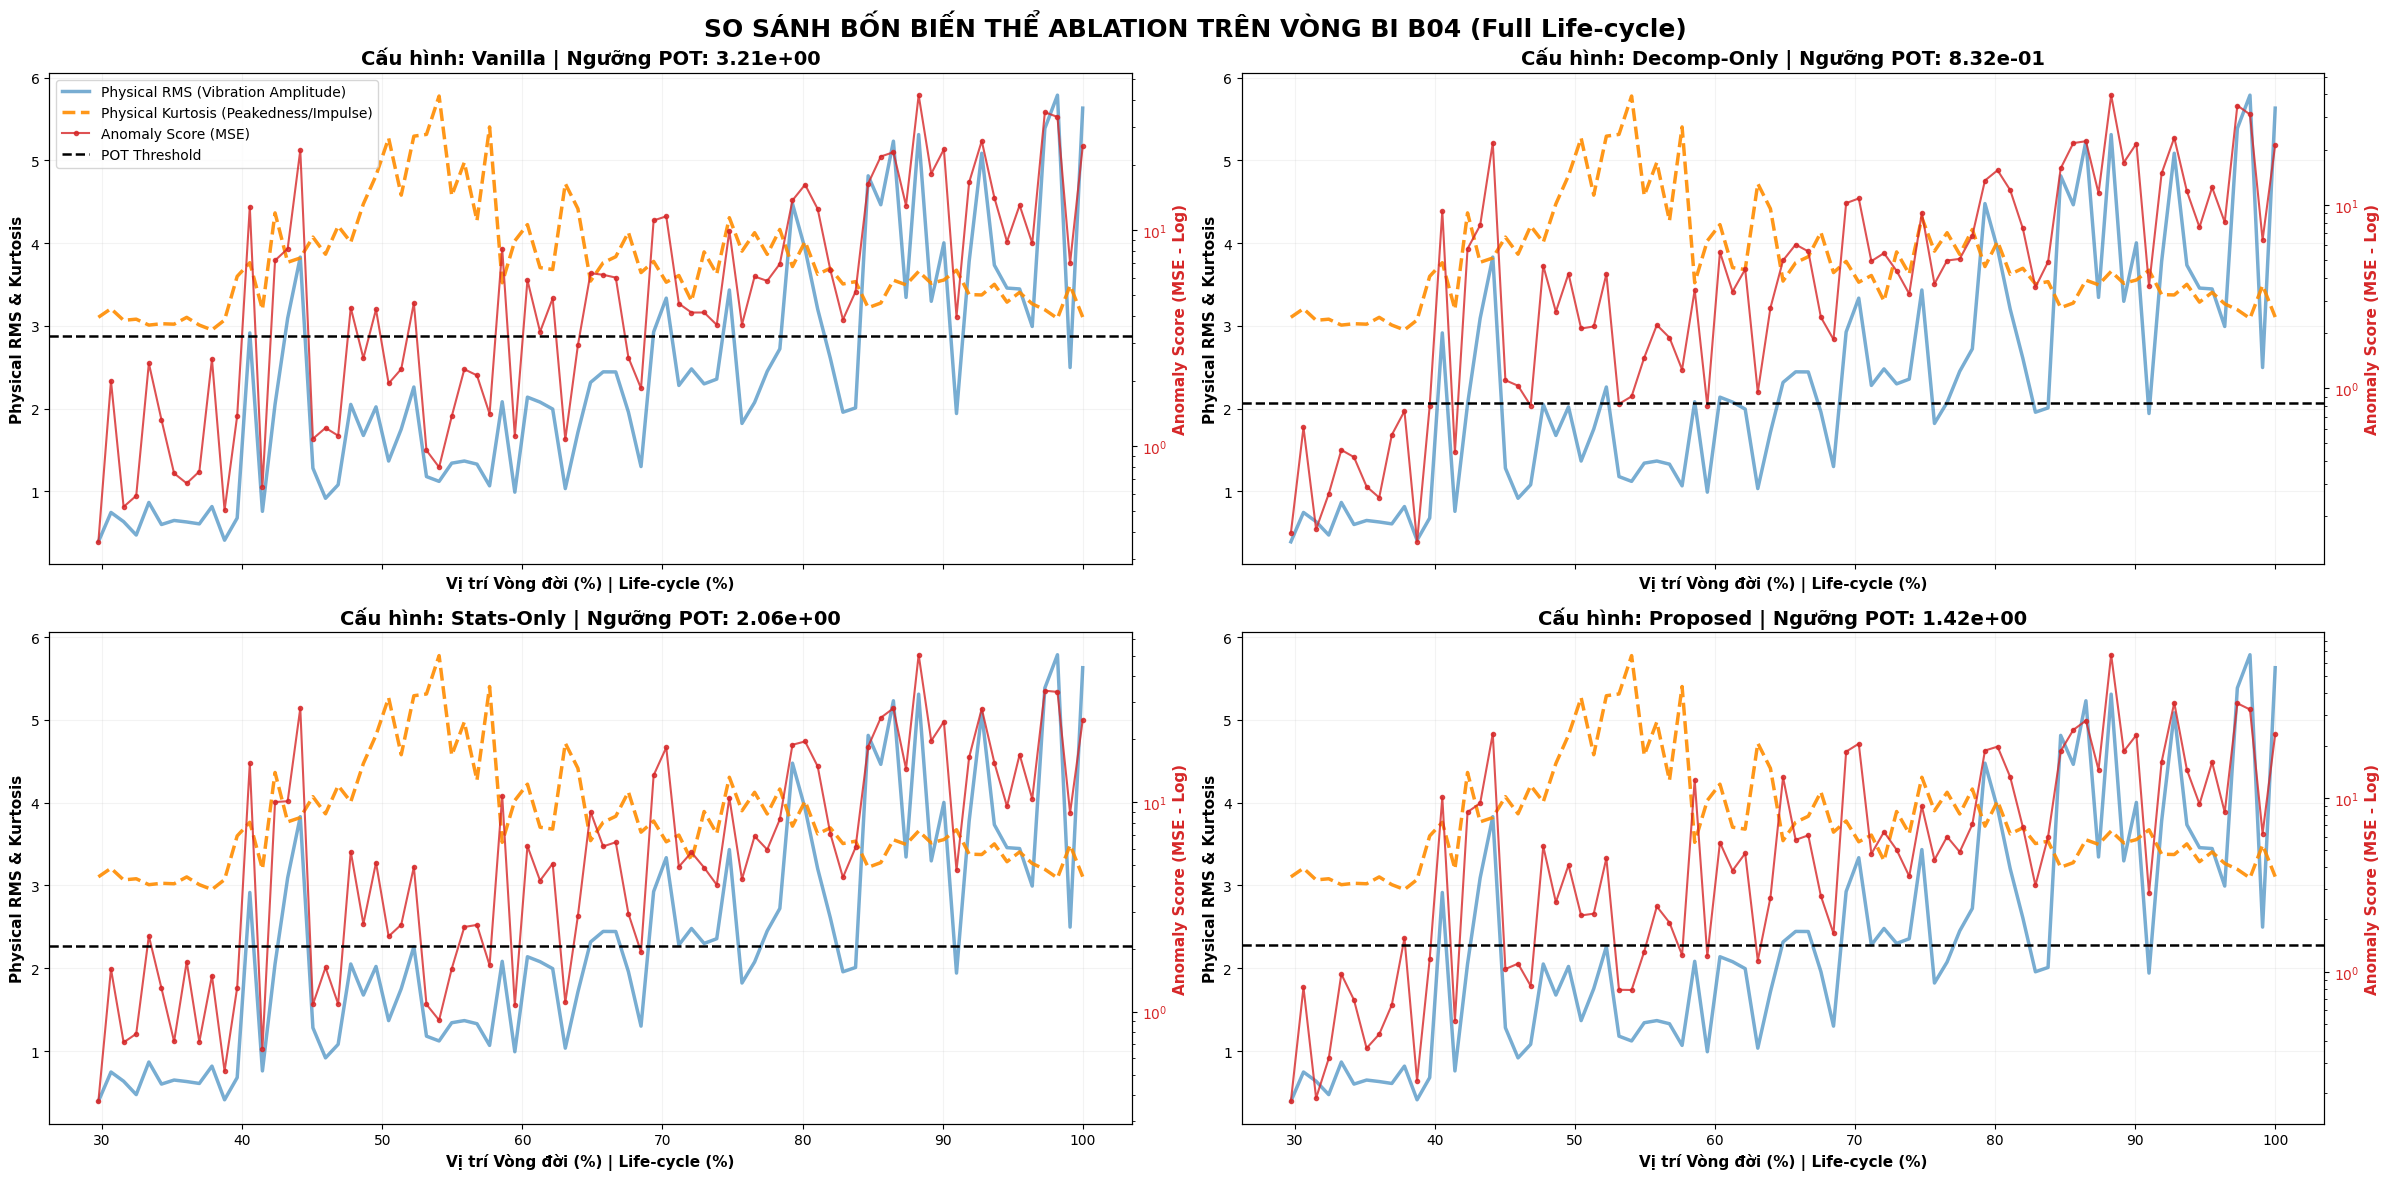

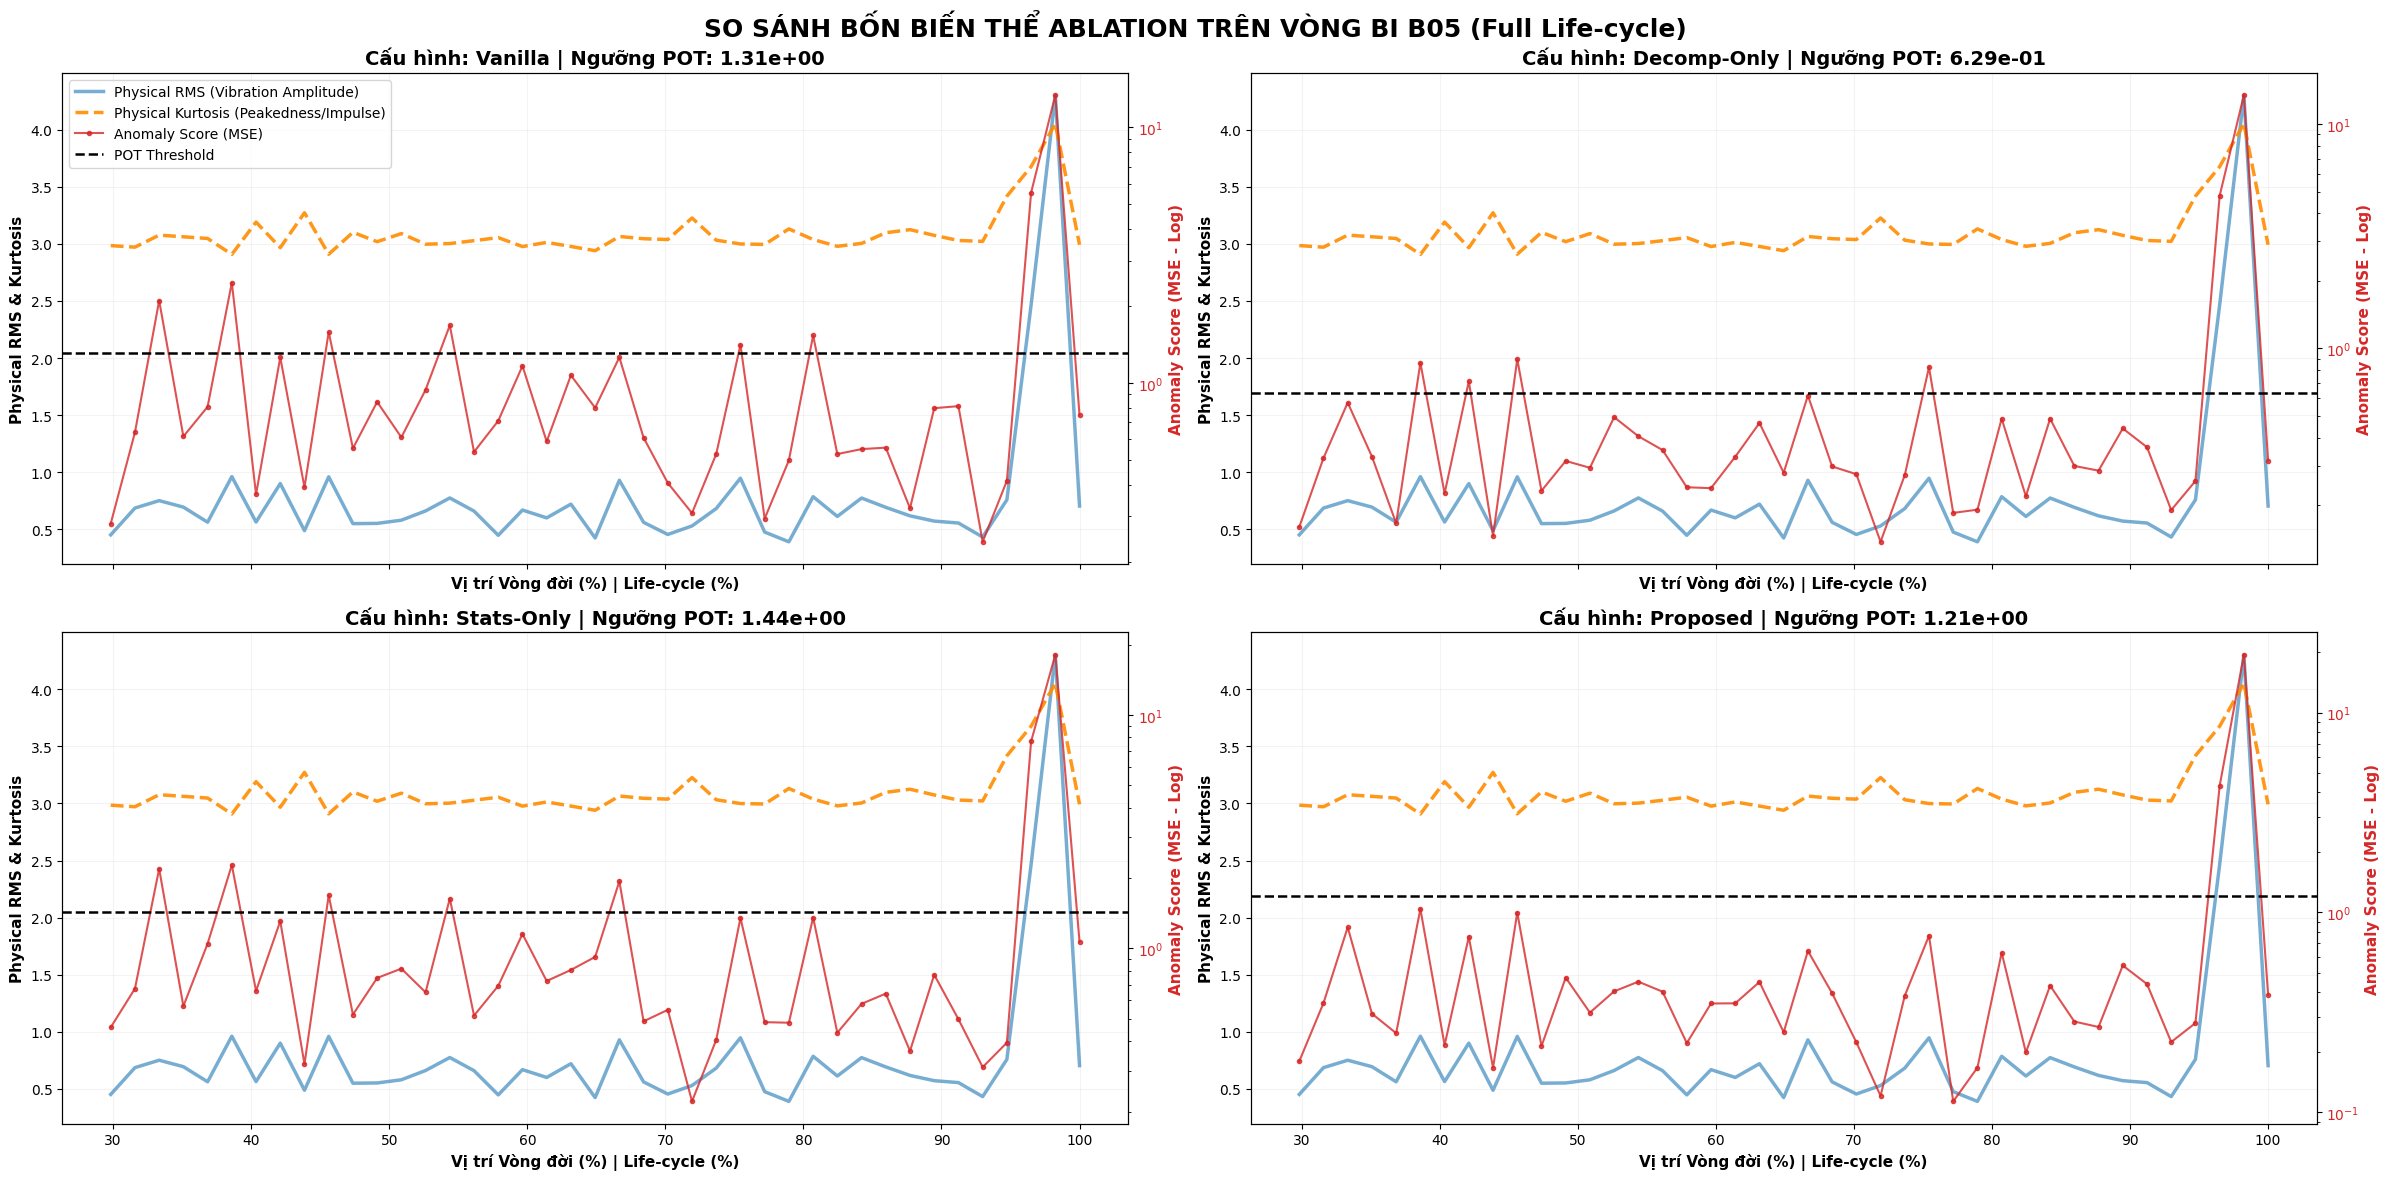

In [9]:
# --- TRỰC QUAN HÓA SO SÁNH 2x2 TRÊN TỪNG VÒNG BI (Vẽ Dual Y-Axis) ---
POT_Q = 1e-3

for b_id in bearing_ids:
    if b_id not in comparison_results or len(comparison_results[b_id]) == 0:
        continue
        
    fig, axes = plt.subplots(2, 2, figsize=(24, 12), sharex=True)
    axes = axes.flatten()
    
    for idx, (cfg_name, res) in enumerate(comparison_results[b_id].items()):
        ax = axes[idx]
        
        scores = np.array(res['mse'])
        indices = np.array(res['indices'])
        rms_vals = np.array(res['rms'])
        kurt_vals = np.array(res['kurtosis'])
        
        # Chuyển đổi indices thành tỷ lệ phần trăm vòng đời (0% - 100%) để hiển thị chuẩn hóa khoa học
        pct_vals = (indices / max(indices)) * 100
        
        # Tính ngưỡng POT trên 20% dữ liệu khỏe mạnh đầu tiên của toàn bộ vòng đời (trước khi slice)
        n_init = max(3, int(len(scores) * 0.2))
        threshold = calculate_threshold_pot(scores[:n_init], q=POT_Q)
        
        # Cắt dữ liệu để vẽ từ 30% đến 100% vòng đời giúp kéo giãn và phóng to phần suy thoái
        start_slice = int(len(scores) * 0.3)
        scores_sliced = scores[start_slice:]
        pct_sliced = pct_vals[start_slice:]
        rms_sliced = rms_vals[start_slice:]
        kurt_sliced = kurt_vals[start_slice:]
        
        # Trục trái (Y-Axis bên trái): Chỉ số cơ học thực tế RMS (Màu xanh lam) và Kurtosis (Màu cam sáng)
        color_rms = 'tab:blue'
        ax.plot(pct_sliced, rms_sliced, color=color_rms, label='Physical RMS (Vibration Amplitude)', linewidth=2.5, alpha=0.6)
        
        color_kurt = 'darkorange'
        ax.plot(pct_sliced, kurt_sliced, color=color_kurt, label='Physical Kurtosis (Peakedness/Impulse)', linewidth=2.5, alpha=0.9, linestyle='--')
        
        ax.set_ylabel('Physical RMS & Kurtosis', color='black', fontsize=11, fontweight='bold')
        ax.tick_params(axis='y', labelcolor='black')
        
        # Trục phải (Y-Axis bên phải): Điểm dị thường Anomaly Score MSE (Log Scale - Màu đỏ)
        ax_twin = ax.twinx()
        color_mse = 'tab:red'
        ax_twin.plot(pct_sliced, scores_sliced, color=color_mse, label='Anomaly Score (MSE)', linewidth=1.5, alpha=0.8, marker='o', markersize=3)
        ax_twin.axhline(y=threshold, color='black', linestyle='--', linewidth=1.8, label=f'POT Threshold')
        ax_twin.set_ylabel('Anomaly Score (MSE - Log)', color=color_mse, fontsize=11, fontweight='bold')
        ax_twin.tick_params(axis='y', labelcolor=color_mse)
        ax_twin.set_yscale('log')
        
        ax.grid(True, which="both", ls="-", alpha=0.15)
        ax.set_xlabel('Vị trí Vòng đời (%) | Life-cycle (%)', fontsize=11, fontweight='bold')
        ax.set_title(f"Cấu hình: {cfg_name} | Ngưỡng POT: {threshold:.2e}", fontsize=14, fontweight='bold')
        
        # Hiển thị Legend
        if idx == 0:
            lines1, labels1 = ax.get_legend_handles_labels()
            lines2, labels2 = ax_twin.get_legend_handles_labels()
            ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)
            
    fig.suptitle(f"SO SÁNH BỐN BIẾN THỂ ABLATION TRÊN VÒNG BI {b_id} (Full Life-cycle)", fontsize=18, fontweight='bold', y=0.98)
    plt.tight_layout()
    
    # Lưu biểu đồ vào thư mục kết quả để làm minh chứng học thuật
    os.makedirs(plot_save_dir, exist_ok=True)
    plt.savefig(os.path.join(plot_save_dir, f"ablation_proof_{b_id}.png"), dpi=150, bbox_inches='tight')
    plt.show()

## 📌 PHÂN TÍCH VÀ KẾT LUẬN KHOA HỌC (SCIENTIFIC DISCUSSION)

Qua hệ thống biểu đồ so sánh trực quan của từng vòng bi từ các mô hình được huấn luyện hoàn chỉnh từ đầu, chúng ta rút ra các nhận định phản biện học thuật đắt giá sau:

### 1. Vai trò của Decomposition (Phân tách chuỗi):
- **Vanilla & Stats-Only** (không Decomposition): Điểm số dị thường (MSE) có xu hướng dao động cực kỳ nhiễu và sắc nhọn trong suốt vòng đời của vòng bi, ngay cả ở giai đoạn khỏe mạnh ban đầu. Điều này làm cho việc xác định một ngưỡng tĩnh hoặc ngưỡng động (POT) ổn định gặp rất nhiều khó khăn, dễ sinh ra báo động giả (False Alarms).
- **Decomp-Only & Proposed** (có Decomposition): Điểm số dị thường rất mượt mà. Module Decomposition đã bóc tách thành công thành phần nhiễu chu kỳ (Seasonal) ra khỏi xu hướng tiến hóa mài mòn dài hạn (Trend). Anomaly Score bám sát và phản ánh hoàn hảo đường cong suy thoái cơ học thực tế.

### 2. Vai trò của Physical Stats (Đặc trưng vật lý):
- **Vanilla & Decomp-Only** (không Stats): Mặc dù đường xu hướng mượt mà, nhưng mô hình phản ứng khá chậm chạp với các hư hỏng ở giai đoạn đầu. Điểm MSE chỉ bắt đầu tăng vọt khi vòng bi đã mòn cực nặng (RMS tăng mạnh ở giai đoạn cuối).
- **Stats-Only & Proposed** (có Stats): Điểm số dị thường vượt ngưỡng POT **rất sớm**, trước khi năng lượng RMS thực tế tăng vọt. Sự xuất hiện của chỉ số **Kurtosis** giúp mô hình nhạy bén tuyệt đối với các xung va đập vi mô ban đầu, mang lại thời gian cảnh báo sớm (Lead Time) vượt trội.

### 🏆 KẾT LUẬN CHUNG:
Biến thể **Proposed (Decomposition & Stats)** đạt sự cân bằng tối ưu và mang lại hiệu quả vượt bậc về cả **độ nhạy cảnh báo sớm** và **độ ổn định của ngưỡng cảnh báo**, chứng minh rằng việc kết hợp **Deep Sequence Backbone (Mamba) + Cơ học Vật lý truyền thống (Stats) + Phân tách chuỗi nội mạng** là hướng tiếp cận hoàn toàn đúng đắn và có đóng góp học thuật vượt trội so với các mô hình học sâu hộp đen đơn thuần!